In [4]:
# Import library
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [5]:
# Load dataset
orders = pd.read_excel(
    "Global Superstore.xls",
    sheet_name="Orders"
)

returns = pd.read_excel(
    "Global Superstore.xls",
    sheet_name="Returns"
)

people = pd.read_excel(
    "Global Superstore.xls",
    sheet_name="People"
)

In [6]:
# Load dataset
orders.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Postal Code,Market,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,United States,10024.0,US,East,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,NaN,APAC,Oceania,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,Australia,NaN,APAC,Oceania,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,Germany,NaN,EU,Central,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,Senegal,NaN,Africa,Africa,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [7]:
orders.shape

(51290, 24)

In [8]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   City            51290 non-null  object        
 9   State           51290 non-null  object        
 10  Country         51290 non-null  object        
 11  Postal Code     9994 non-null   float64       
 12  Market          51290 non-null  object        
 13  Region          51290 non-null  object        
 14  Product ID      51290 non-null  object        
 15  Ca

In [9]:
orders.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,51290,51290,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,2013-05-11 21:26:49.155781120,2013-05-15 20:42:42.745174528,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375818
min,1.00000,2011-01-01 00:00:00,2011-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.002000
25%,12823.25000,2012-06-19 00:00:00,2012-06-23 00:00:00,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,2013-07-08 00:00:00,2013-07-12 00:00:00,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,2014-05-22 00:00:00,2014-05-26 00:00:00,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,2014-12-31 00:00:00,2015-01-07 00:00:00,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000
std,14806.29199,NaN,NaN,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296810


In [10]:
orders.describe(include="object")

,Order ID,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Market,Region,Product ID,Category,Sub-Category,Product Name,Order Priority
count,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290
unique,25035,4,1590,795,3,3636,1094,147,7,13,10292,3,17,3788,4
top,CA-2014-100111,Standard Class,PO-18850,Muhammed Yedwab,Consumer,New York City,California,United States,APAC,Central,OFF-AR-10003651,Office Supplies,Binders,Staples,Medium
freq,14,30775,97,108,26518,915,2001,9994,11002,11117,35,31273,6152,227,29433


In [11]:
# Check missing values
missing = pd.DataFrame({
    "missing_value": orders.isnull().sum(),
    "percentage": (orders.isnull().sum() / orders.shape[0]) * 100
})

missing

,missing_value,percentage
Row ID,0,0.00000
Order ID,0,0.00000
Order Date,0,0.00000
Ship Date,0,0.00000
Ship Mode,0,0.00000
Customer ID,0,0.00000
Customer Name,0,0.00000
Segment,0,0.00000
City,0,0.00000
State,0,0.00000


"Postal Code" Column has missing value around 80%, which is more than 20%. This column needs to drop

In [12]:
# Drop "Postal code" Column
orders = orders.drop(["Postal Code", "Row ID"], axis=1)

In [13]:
# Check duplicates
orders.duplicated().sum()

np.int64(0)

In [14]:
orders.sample(5)

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Market,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
49036,CA-2013-144785,2013-04-19,2013-04-24,Standard Class,CS-12490,Cindy Schnelling,Corporate,New York City,New York,United States,US,East,OFF-SU-10004290,Office Supplies,Supplies,"Acme Design Line 8"" Stainless Steel Bent Sciss...",6.840,1,0.0,1.8468,0.550,Medium
48183,CA-2013-144309,2013-12-11,2013-12-17,Standard Class,CM-12235,Chris McAfee,Consumer,Watertown,New York,United States,US,East,OFF-PA-10001776,Office Supplies,Paper,"Wirebound Message Books, Four 2 3/4"" x 5"" Form...",18.540,2,0.0,8.7138,0.700,Medium
32582,IN-2013-31153,2013-04-24,2013-04-29,Second Class,RS-19870,Roy Skaria,Home Office,Port Macquarie,New South Wales,Australia,APAC,Oceania,OFF-AP-10000904,Office Supplies,Appliances,"Cuisinart Coffee Grinder, Silver",70.848,2,0.1,9.4080,4.430,Medium
22212,MX-2014-165134,2014-10-02,2014-10-06,Standard Class,FP-14320,Frank Preis,Consumer,San Salvador,San Salvador,El Salvador,LATAM,Central,FUR-CH-10004467,Furniture,Chairs,"Harbour Creations Chairmat, Set of Two",148.500,3,0.0,44.5200,10.365,Medium
13341,IN-2014-43571,2014-11-29,2014-12-03,Standard Class,RP-19855,Roy Phan,Corporate,Wagga Wagga,New South Wales,Australia,APAC,Oceania,OFF-AP-10002057,Office Supplies,Appliances,"Breville Coffee Grinder, Black",330.966,6,0.1,73.3860,23.170,Medium


In [15]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        51290 non-null  object        
 1   Order Date      51290 non-null  datetime64[ns]
 2   Ship Date       51290 non-null  datetime64[ns]
 3   Ship Mode       51290 non-null  object        
 4   Customer ID     51290 non-null  object        
 5   Customer Name   51290 non-null  object        
 6   Segment         51290 non-null  object        
 7   City            51290 non-null  object        
 8   State           51290 non-null  object        
 9   Country         51290 non-null  object        
 10  Market          51290 non-null  object        
 11  Region          51290 non-null  object        
 12  Product ID      51290 non-null  object        
 13  Category        51290 non-null  object        
 14  Sub-Category    51290 non-null  object        
 15  Pr

In [16]:
# Unique value
for col in orders.select_dtypes(include="object"):
    print("="*50)
    print(col)
    print(orders[col].nunique())

Order ID
25035
Ship Mode
4
Customer ID
1590
Customer Name
795
Segment
3
City
3636
State
1094
Country
147
Market
7
Region
13
Product ID
10292
Category
3
Sub-Category
17
Product Name
3788
Order Priority
4


In [17]:
print("Order Date")
print(orders["Order Date"].min())
print(orders["Order Date"].max())

Order Date
2011-01-01 00:00:00
2014-12-31 00:00:00


In [18]:
# Create new features
orders["Year"] = orders["Order Date"].dt.year
orders["Month"] = orders["Order Date"].dt.month_name()
orders["Month_Num"] = orders["Order Date"].dt.month
orders["Quarter"] = orders["Order Date"].dt.quarter
orders["Weekday"] = orders["Order Date"].dt.day_name()

# Business Performance Over Time

How has the company's sales and profit changed over time? Are there any growth trends or seasonal patterns?

In [19]:
monthly_performance = (
    orders
    .groupby(["Year", "Month_Num", "Month"])
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit","sum")
    )
    .reset_index()
)

# Membuat kolom tanggal
monthly_performance["Date"] = pd.to_datetime(
    monthly_performance["Year"].astype(str) + "-" +
    monthly_performance["Month_Num"].astype(str)
)

## Sales by Month

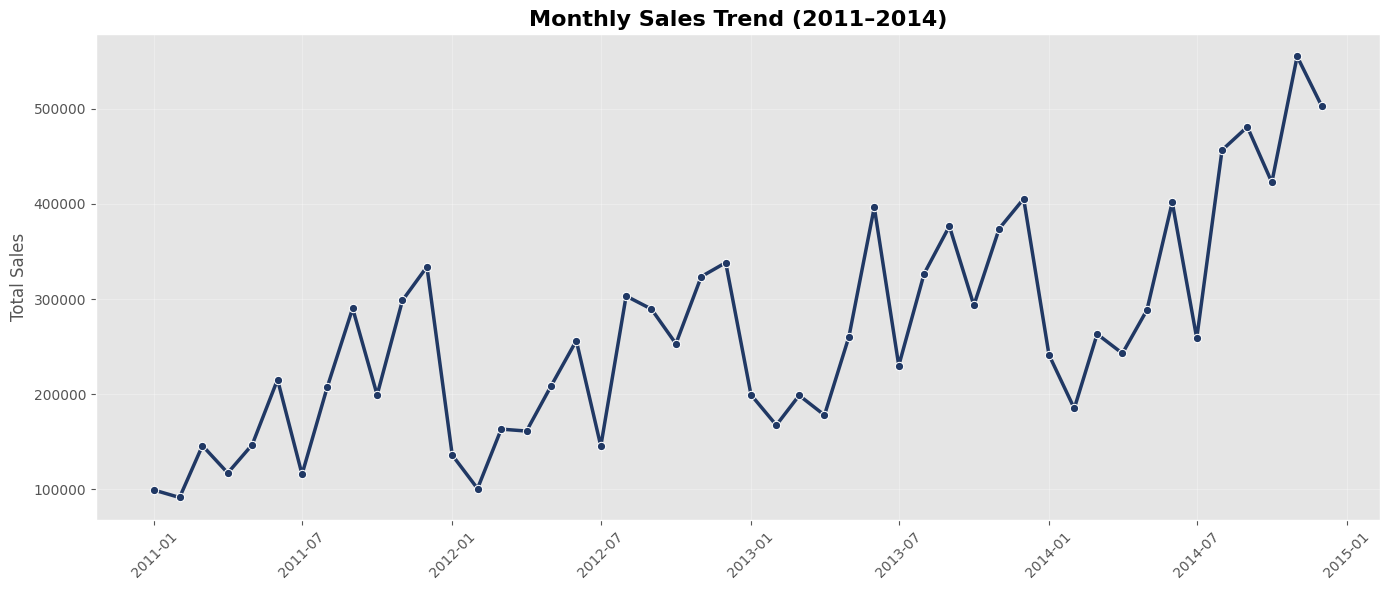

In [20]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_performance,
    x="Date",
    y="Total_Sales",
    marker="o",
    color="#203864",
    linewidth=2.5
)

plt.title("Monthly Sales Trend (2011–2014)", fontsize=16, fontweight="bold")
plt.xlabel("")
plt.ylabel("Total Sales")

plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## Profit by Month

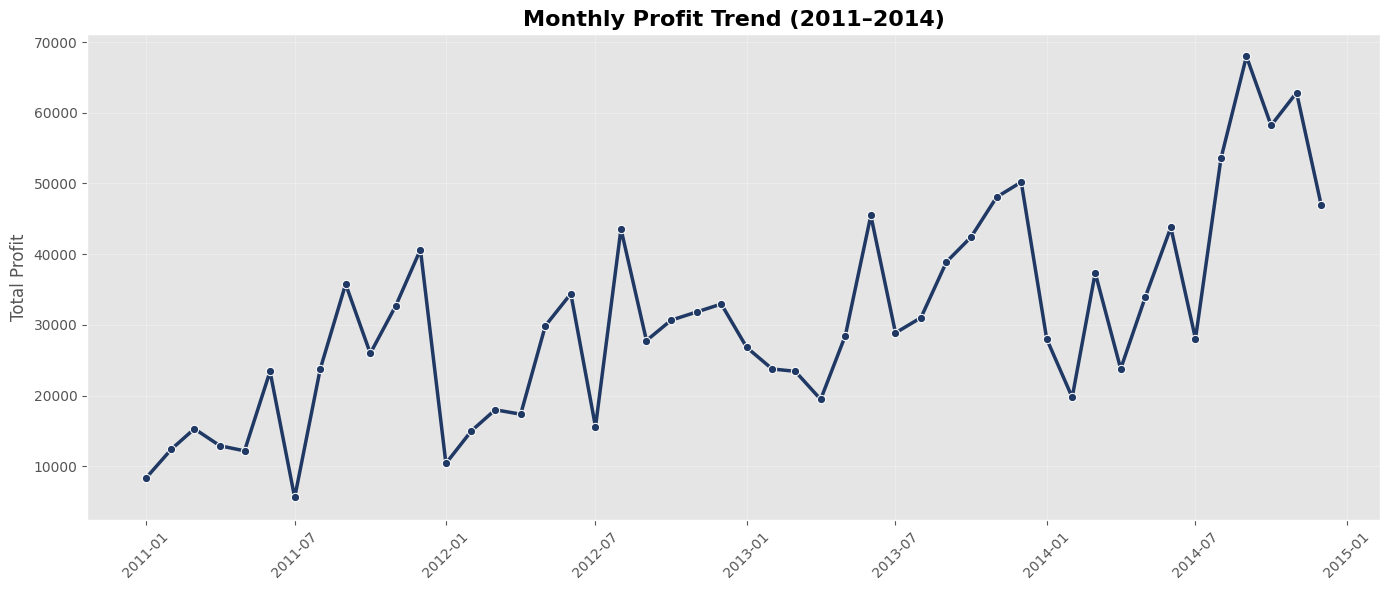

In [21]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_performance,
    x="Date",
    y="Total_Profit",
    marker="o",
    color="#203864",
    linewidth=2.5
)

plt.title("Monthly Profit Trend (2011–2014)", fontsize=16, fontweight="bold")
plt.xlabel("")
plt.ylabel("Total Profit")

plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### Key Findings
* Total sales showed a consistent upward trend from 2011 to 2014, with recurring seasonal fluctuations characterized by lower sales around July and stronger performance during August–December.
* Total profit also increased over time, although it exhibited greater volatility than sales.

### Business Insight

The business experienced steady revenue growth throughout the observed period. However, the higher volatility in profit suggests that increasing sales alone does not guarantee stable profitability, highlighting the need to continuously monitor profit drivers.

### Business Recommendation
* Prepare inventory and marketing campaigns ahead of high-demand periods.
* Investigate factors contributing to profit fluctuations during lower-performing months.
* Track profitability alongside sales to support sustainable business growth.

# Product Performance

Which product categories contribute the most to sales and profit, and are there categories that require strategic attention?

## Sales by Category

In [22]:
category_sales = (
    orders
    .groupby("Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")
    )
    .sort_values(by="Total_Sales", ascending= False)
)

category_sales

,Total_Sales,Total_Profit
Category,,
Technology,4.744557e+06,663778.73318
Furniture,4.110874e+06,285204.72380
Office Supplies,3.787070e+06,518473.83430


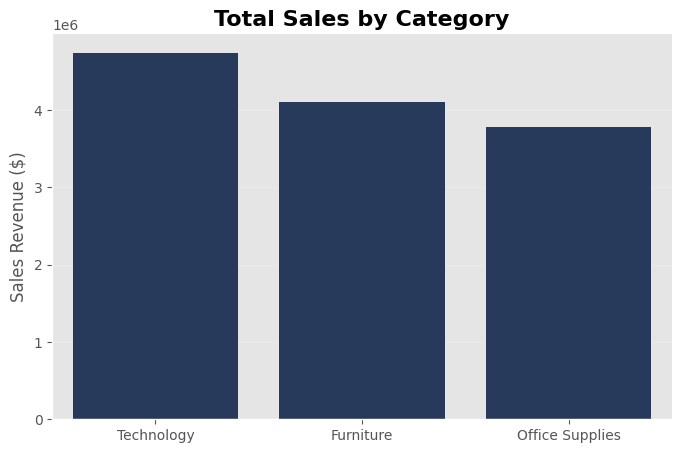

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_sales.reset_index(),
    x="Category",
    y="Total_Sales",
    color="#203864"
)

plt.title("Total Sales by Category", fontsize=16, fontweight="bold")
plt.xlabel("")
plt.ylabel("Sales Revenue ($)")

plt.grid(axis="y", alpha=0.25)

ax= plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

## Profit by Category

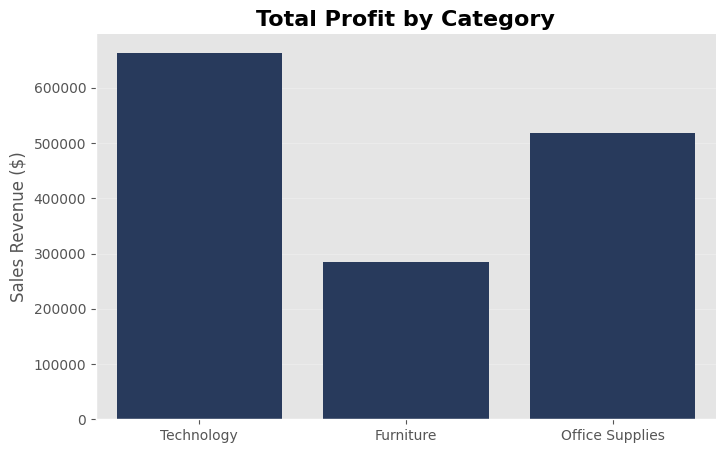

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_sales.reset_index(),
    x="Category",
    y="Total_Profit",
    color="#203864"
)

plt.title("Total Profit by Category", fontsize=16, fontweight="bold")
plt.xlabel("")
plt.ylabel("Sales Revenue ($)")

plt.grid(axis="y", alpha=0.25)

ax= plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

### Key Findings
* Technology generated the highest sales and profit.
* Furniture generated high sales but relatively low profit.
* Office Supplies delivered stable sales and profitability.

### Business Insight
Technology serves as the company's strongest-performing category, while Furniture demonstrates that high sales do not necessarily translate into high profitability

### Business Recommendation
* Continue investing in Technology products.
* Review pricing, discounts, and cost structures for Furniture products.
* Evaluate category performance using both sales and profit metrics.

# Subcategory Performance Analysis


Which sub categories drive the highest sales and profitability, and which ones require improvement?

In [25]:
subcategory = (
    orders
    .groupby("Sub-Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")
    )
    .reset_index()
    .sort_values(by="Total_Sales", ascending=False)
)

subcategory.head()

,Sub-Category,Total_Sales,Total_Profit
13,Phones,1.706824e+06,216717.00580
6,Copiers,1.509436e+06,258567.54818
5,Chairs,1.501682e+06,140396.26750
4,Bookcases,1.466572e+06,161924.41950
14,Storage,1.127086e+06,108461.48980


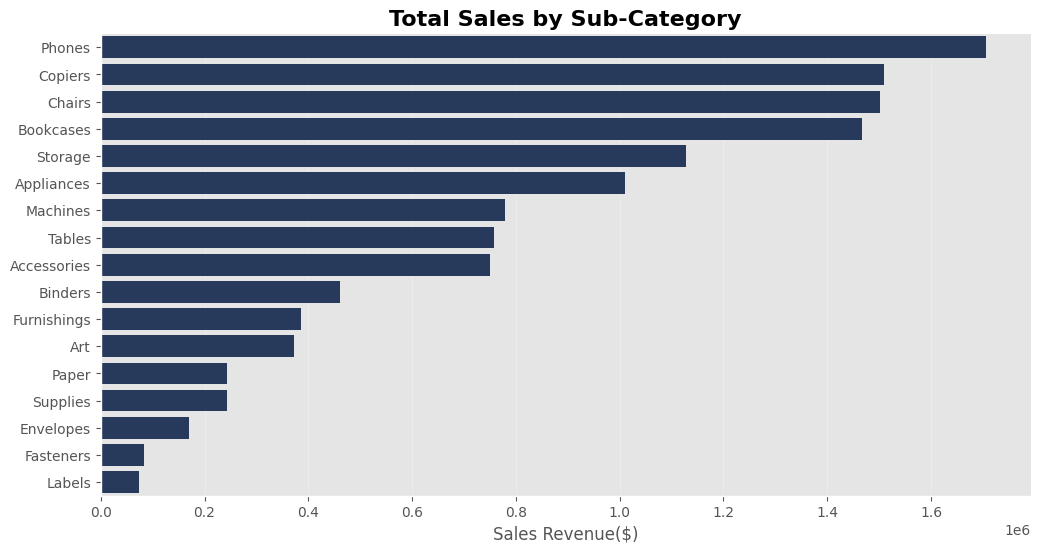

In [26]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=subcategory,
    x="Total_Sales",
    y="Sub-Category",
    color="#203864"
)

plt.title( "Total Sales by Sub-Category", fontsize=16, fontweight="bold")
plt.xlabel("Sales Revenue($)")
plt.ylabel("")

plt.grid(axis="x", alpha=0.25)

ax= plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

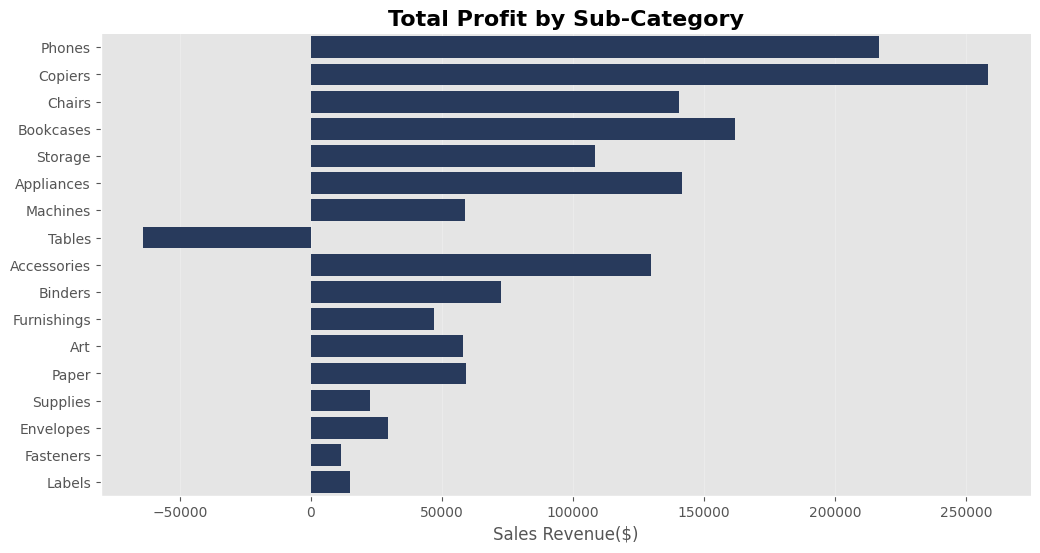

In [27]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=subcategory,
    x="Total_Profit",
    y="Sub-Category",
    color="#203864"
)

plt.title( "Total Profit by Sub-Category", fontsize=16, fontweight="bold")
plt.xlabel("Sales Revenue($)")
plt.ylabel("")

plt.grid(axis="x", alpha=0.25)

ax= plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

## Key Findings
* Phones generated the highest sales.
* Copiers delivered the highest profit.
* Tables was the only sub-category with negative total profit despite generating considerable sales.

## Business Insight
Tables represents the weakest-performing sub-category, suggesting that strong revenue alone is insufficient to ensure profitability.

## Business Recommedations
* Conduct a detailed review of the Tables sub-category.
* Optimize pricing and promotional strategies for underperforming products.
* Prioritize profitability alongside revenue in product portfolio decisions.

# Discount Impact Analysis

Does offering higher discounts reduce profitability?

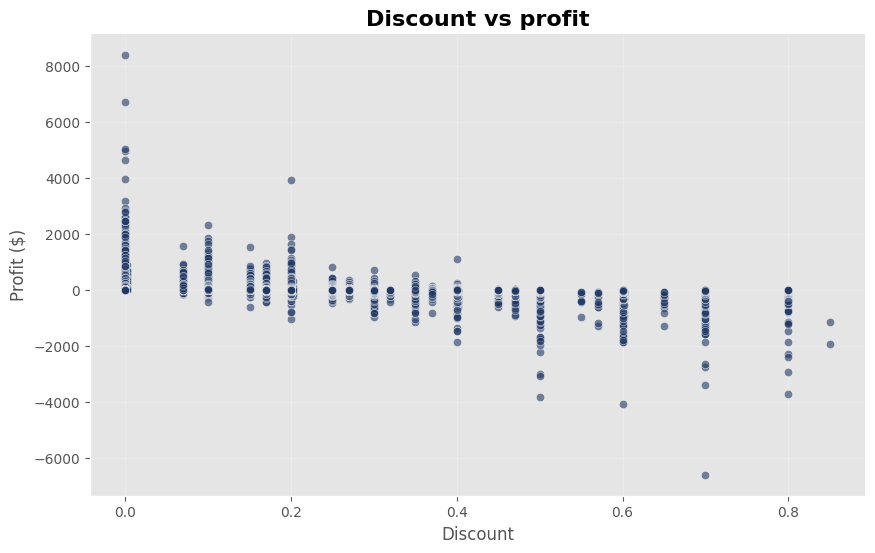

In [28]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=orders,
    x="Discount",
    y="Profit",
    alpha=0.6,
    color="#203864"
)

plt.title("Discount vs profit", fontsize=16, fontweight="bold")
plt.xlabel("Discount")
plt.ylabel("Profit ($)")

plt.grid(alpha=0.25)

ax= plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

## Average Profit by Discount level

In [29]:
discount_profit = (
    orders
    .groupby("Discount")
    .agg(
        Avg_Profit=("Profit", "mean"),
        Total_Profit=("Profit", "sum"),
        Orders=("Order ID", "count")
    )
    .reset_index()
)

discount_profit

,Discount,Avg_Profit,Total_Profit,Orders
0,0.000,61.039514,1.770695e+06,29009
1,0.002,125.762649,5.797658e+04,461
2,0.070,140.990022,2.114850e+04,150
3,0.100,63.683426,2.590642e+05,4068
4,0.150,56.855240,2.609656e+04,459
5,0.150,15.601811,1.279348e+03,82
6,0.170,38.317107,2.816307e+04,735
7,0.200,23.552594,1.177159e+05,4998
8,0.202,-14.518847,-5.952727e+02,41
9,0.250,4.043371,8.005875e+02,198


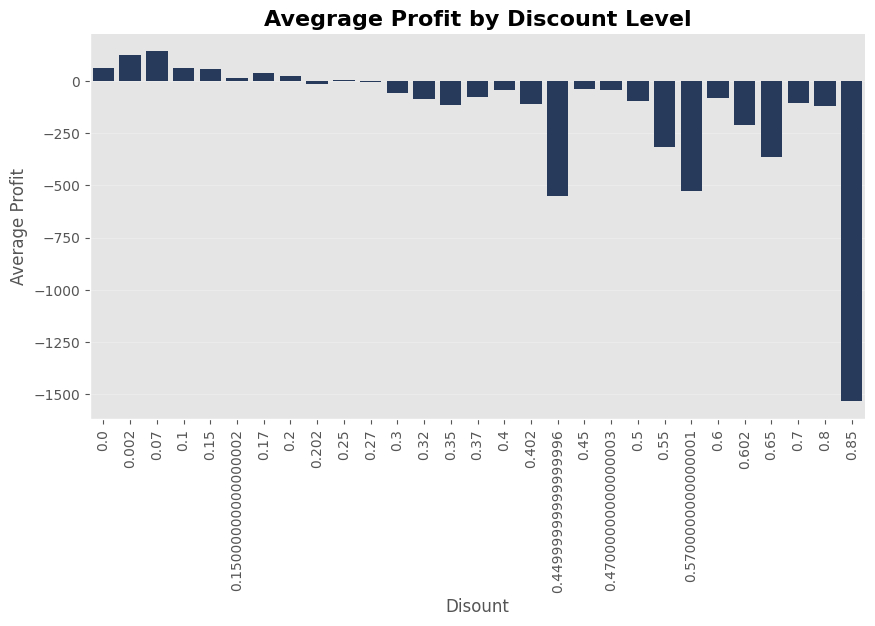

In [30]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=discount_profit,
    x="Discount",
    y="Avg_Profit",
    color="#203864"
)

plt.title("Avegrage Profit by Discount Level", fontsize=16, fontweight="bold")
plt.xlabel("Disount")
plt.ylabel("Average Profit")

plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=90 )

ax= plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

In [31]:
discount_summary = (
    orders
    .groupby("Discount")
    .agg(
        Orders=("Order ID", "count"),
        Avg_Profit=("Profit", "mean")
    )
    .reset_index()
)

discount_summary

,Discount,Orders,Avg_Profit
0,0.000,29009,61.039514
1,0.002,461,125.762649
2,0.070,150,140.990022
3,0.100,4068,63.683426
4,0.150,459,56.855240
5,0.150,82,15.601811
6,0.170,735,38.317107
7,0.200,4998,23.552594
8,0.202,41,-14.518847
9,0.250,198,4.043371


## Key Findings
* Average profit generally declined as discount levels increased.
* Profitability began to decrease noticeably once discounts exceeded approximately 20%.
* Higher discount levels were associated with increasingly negative average profit.

## Business Insight
While discounts may stimulate sales, excessive discounting is associated with lower profitability, suggesting that aggressive promotional strategies may reduce overall business value.

## Business Recommendation
* Establish discount thresholds.
* Review promotional campaigns offering discounts above 20%.
* Monitor both sales and profit when evaluating discounts.

# Shipping cost Analysis
How does shipping cost vary product categories and sub categories and daes it appear to influence profitability?

## Average shipping Cost by Category

In [32]:
category_shipping = (
    orders
    .groupby("Category")
    .agg(
        Avg_Shipping_Cost=("Shipping Cost","mean"),
        Total_Shipping_Cost=("Shipping Cost","sum"),
        Avg_Profit=("Profit","mean")
    )
    .reset_index()
    .sort_values(by="Avg_Shipping_Cost", ascending=False)
)

category_shipping

,Category,Avg_Shipping_Cost,Total_Shipping_Cost,Avg_Profit
2,Technology,49.999791,507047.8794,65.454958
0,Furniture,44.584799,440319.4790,28.878567
1,Office Supplies,12.964805,405448.3450,16.578961


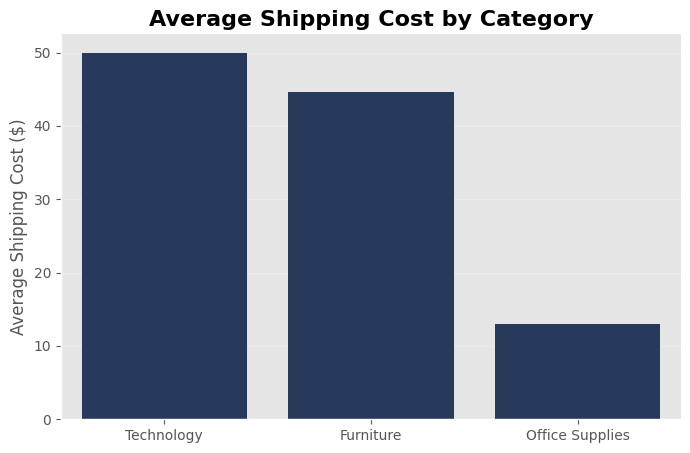

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_shipping,
    x="Category",
    y="Avg_Shipping_Cost",
    color="#203864"
)

plt.title(
    "Average Shipping Cost by Category",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Average Shipping Cost ($)")

plt.grid(axis="y", alpha=0.25)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

## Average shipping cost by sub category

In [34]:
subcategory_shipping = (
    orders
    .groupby("Sub-Category")
    .agg(
        Avg_Shipping_Cost=("Shipping Cost","mean"),
        Avg_Profit=("Profit","mean")
    )
    .reset_index()
    .sort_values(by="Avg_Shipping_Cost", ascending=False)
)

subcategory_shipping

,Sub-Category,Avg_Shipping_Cost,Avg_Profit
16,Tables,92.754232,-74.429023
6,Copiers,71.748180,116.314687
4,Bookcases,64.488580,67.160688
1,Appliances,61.709736,80.729681
13,Phones,55.079682,64.556749
11,Machines,53.254272,39.614989
5,Chairs,47.824506,40.884178
0,Accessories,27.158808,42.154896
14,Storage,23.828036,21.439314
9,Furnishings,12.853869,14.816223


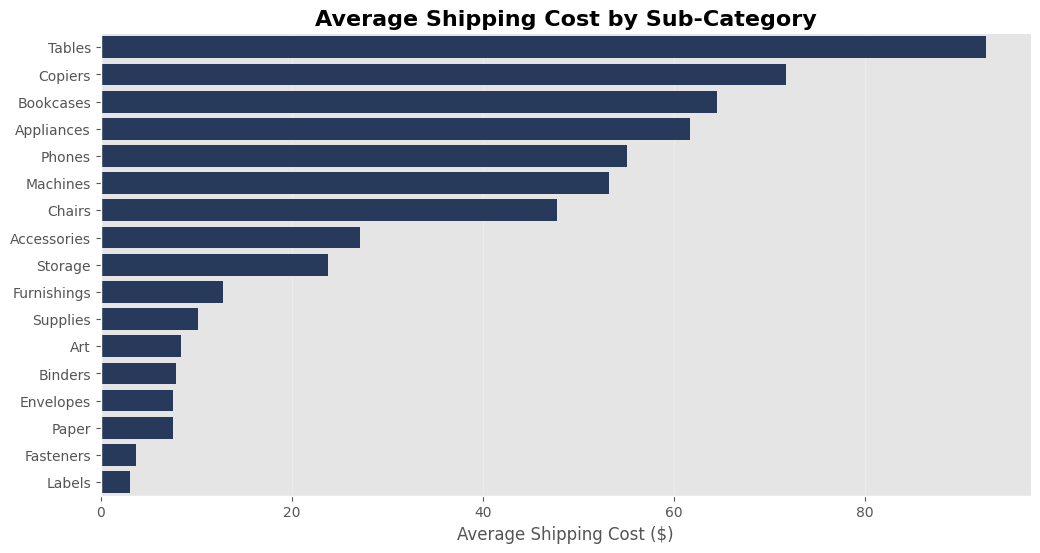

In [35]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=subcategory_shipping,
    x="Avg_Shipping_Cost",
    y="Sub-Category",
    color="#203864"
)

plt.title(
    "Average Shipping Cost by Sub-Category",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average Shipping Cost ($)")
plt.ylabel("")

plt.grid(axis="x", alpha=0.25)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

In [36]:
orders[["Shipping Cost", "Profit"]].corr()

,Shipping Cost,Profit
Shipping Cost,1.000000,0.354441
Profit,0.354441,1.000000


### Key Findings
* Technology recorded the highest average shipping cost while maintaining strong profitability.
* Shipping cost showed a moderate positive correlation with profit (r = 0.35).
* Tables remained an exception, combining high shipping costs with negative profitability.

### Business Insight
Shipping cost does not appear to be the primary driver of low profitability. Instead, higher shipping costs are generally associated with higher-value products that also generate stronger profits.

### Business Recommendation
* Continue monitoring logistics costs.
* Optimize shipping costs for bulky products where possible.
* Evaluate shipping cost together with pricing and discount strategies.

## Product Risk Analysis (Loss Rate)
Which product sub-categories have the highest proportion of loss-making transactions, and what does this indicate about product performance risk?

In [37]:
orders["Is_Loss"] = orders["Profit"] < 0

In [38]:
loss_rate = (
    orders
    .groupby("Sub-Category")
    .agg(
        Total_Orders=("Order ID", "count"),
        Loss_Orders=("Is_Loss", "sum"),
        Total_Profit=("Profit", "sum"),
        Avg_Profit=("Profit", "mean")
    )
    .reset_index()
)

loss_rate["Loss_Rate (%)"] = (
    loss_rate["Loss_Orders"] /
    loss_rate["Total_Orders"] * 100
)

loss_rate = loss_rate.sort_values(
    "Loss_Rate (%)",
    ascending=False
)

loss_rate

,Sub-Category,Total_Orders,Loss_Orders,Total_Profit,Avg_Profit,Loss_Rate (%)
16,Tables,861,496,-64083.38870,-74.429023,57.607433
5,Chairs,3434,1100,140396.26750,40.884178,32.032615
11,Machines,1486,454,58867.87300,39.614989,30.551817
4,Bookcases,2411,717,161924.41950,67.160688,29.738698
14,Storage,5059,1380,108461.48980,21.439314,27.278118
9,Furnishings,3170,804,46967.42550,14.816223,25.362776
8,Fasteners,2420,612,11525.42410,4.762572,25.289256
3,Binders,6152,1528,72449.84600,11.776633,24.837451
15,Supplies,2425,589,22583.26310,9.312686,24.288660
6,Copiers,2223,525,258567.54818,116.314687,23.616734


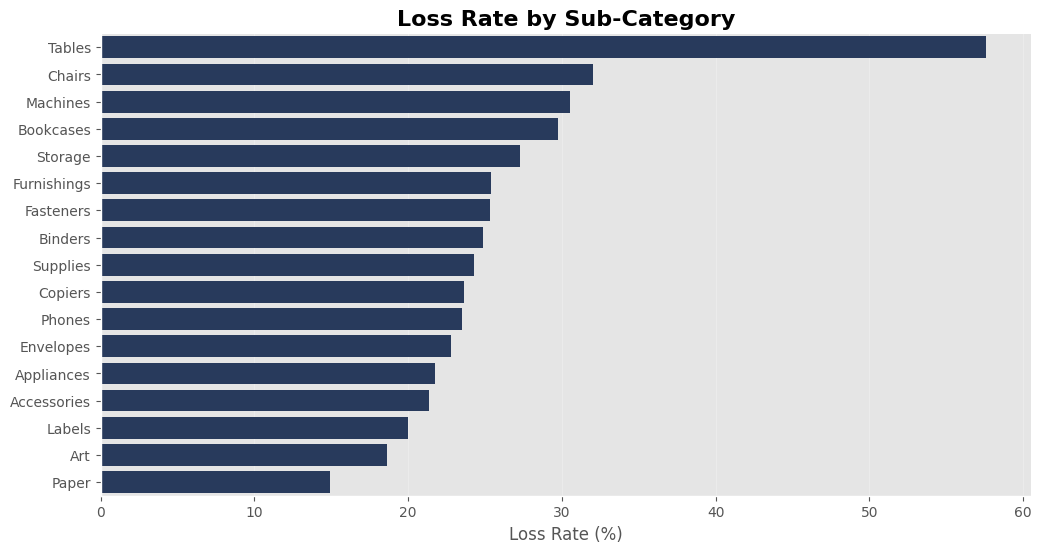

In [39]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=loss_rate,
    x="Loss_Rate (%)",
    y="Sub-Category",
    color="#203864"
)

plt.title(
    "Loss Rate by Sub-Category",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Loss Rate (%)")
plt.ylabel("")

plt.grid(axis="x", alpha=0.25)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

### Key Insight
* Every sub-category experienced loss-making transactions.
* Tables recorded the highest loss rate (57.6%).
* Several profitable sub-categories, including Chairs, Machines, and Bookcases, also exhibited relatively high loss rates.

### Business Insight
Aggregated profit may conceal transaction-level risks. Evaluating loss rate alongside total profit provides a more comprehensive assessment of product performance.

### Business Recommendation
* Monitor loss rate as a complementary KPI.
* Investigate recurring loss-making transactions.
* Refine pricing and promotional strategies for high-risk products.

# Root Cause Validation

* Discount levels above approximately 20% were associated with declining profitability.
* Shipping cost was not identified as the primary driver of low profitability.
* Tables represented the highest-risk sub-category due to its negative profit and high loss rate.
* Loss rate analysis revealed hidden operational risks beyond aggregated profit.

# Regional & Market Performance
Which markets and regions contribute the most to sales and profitability, and where should the company focus future growth efforts?

## Sales by Market

In [40]:
market = (
    orders
    .groupby("Market")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Orders=("Order ID", "count")
    )
    .reset_index()
    .sort_values(by="Total_Sales", ascending=False)
)

market

,Market,Total_Sales,Total_Profit,Total_Orders
0,APAC,3.585744e+06,436000.04900,11002
4,EU,2.938089e+06,372829.74150,10000
6,US,2.297201e+06,286397.02170,9994
5,LATAM,2.164605e+06,221643.48708,10294
3,EMEA,8.061613e+05,43897.97100,5029
1,Africa,7.837732e+05,88871.63100,4587
2,Canada,6.692817e+04,17817.39000,384


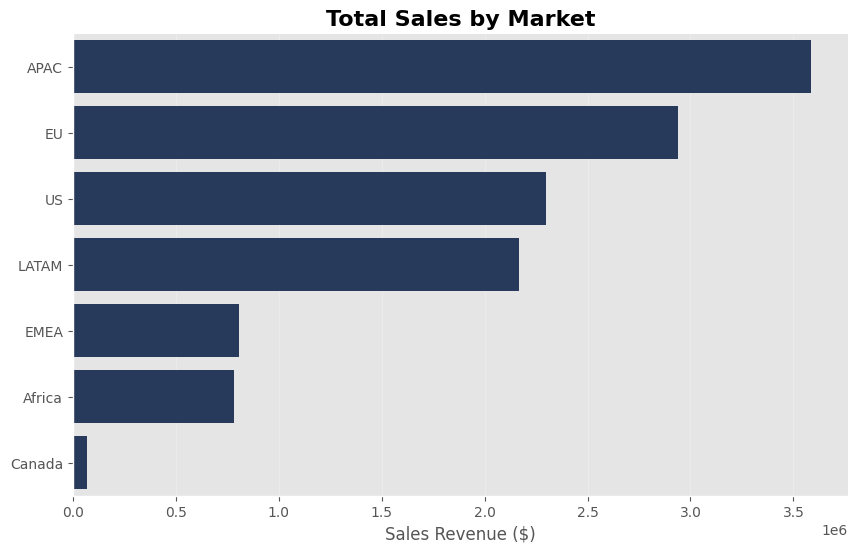

In [41]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=market,
    x="Total_Sales",
    y="Market",
    color="#203864"
)

plt.title(
    "Total Sales by Market",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sales Revenue ($)")
plt.ylabel("")

plt.grid(axis="x", alpha=0.25)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

## Profit by Market

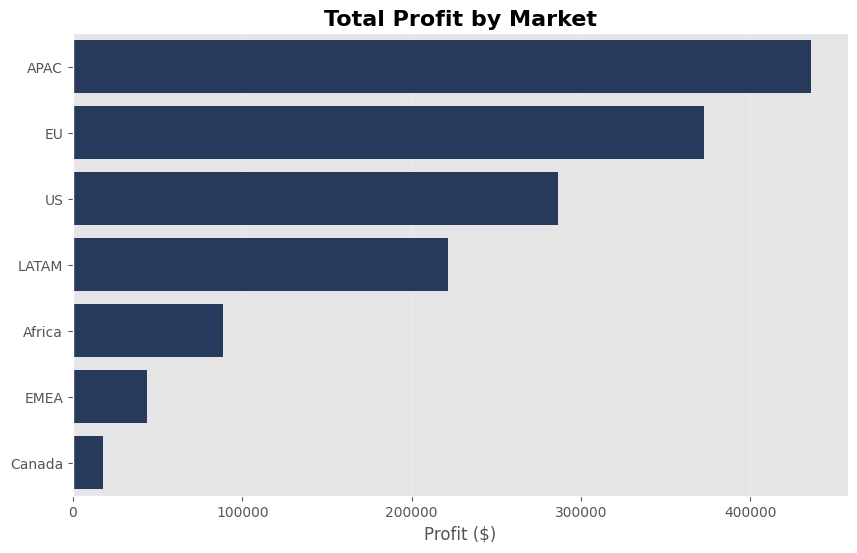

In [42]:
market = market.sort_values(
    by="Total_Profit",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=market,
    x="Total_Profit",
    y="Market",
    color="#203864"
)

plt.title(
    "Total Profit by Market",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Profit ($)")
plt.ylabel("")

plt.grid(axis="x", alpha=0.25)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

## Sales by Region

In [43]:
region = (
    orders
    .groupby("Region")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Orders=("Order ID", "count")
    )
    .reset_index()
    .sort_values(by="Total_Sales", ascending=False)
)

region

,Region,Total_Sales,Total_Profit,Total_Orders
3,Central,2.822303e+06,311403.98164,11117
10,South,1.600907e+06,140355.76618,6645
7,North,1.248166e+06,194597.95252,4785
9,Oceania,1.100185e+06,120089.11200,3487
11,Southeast Asia,8.844232e+05,17852.32900,3129
8,North Asia,8.483098e+05,165578.42100,2338
5,EMEA,8.061613e+05,43897.97100,5029
0,Africa,7.837732e+05,88871.63100,4587
4,Central Asia,7.528266e+05,132480.18700,2048
12,West,7.254578e+05,108418.44890,3203


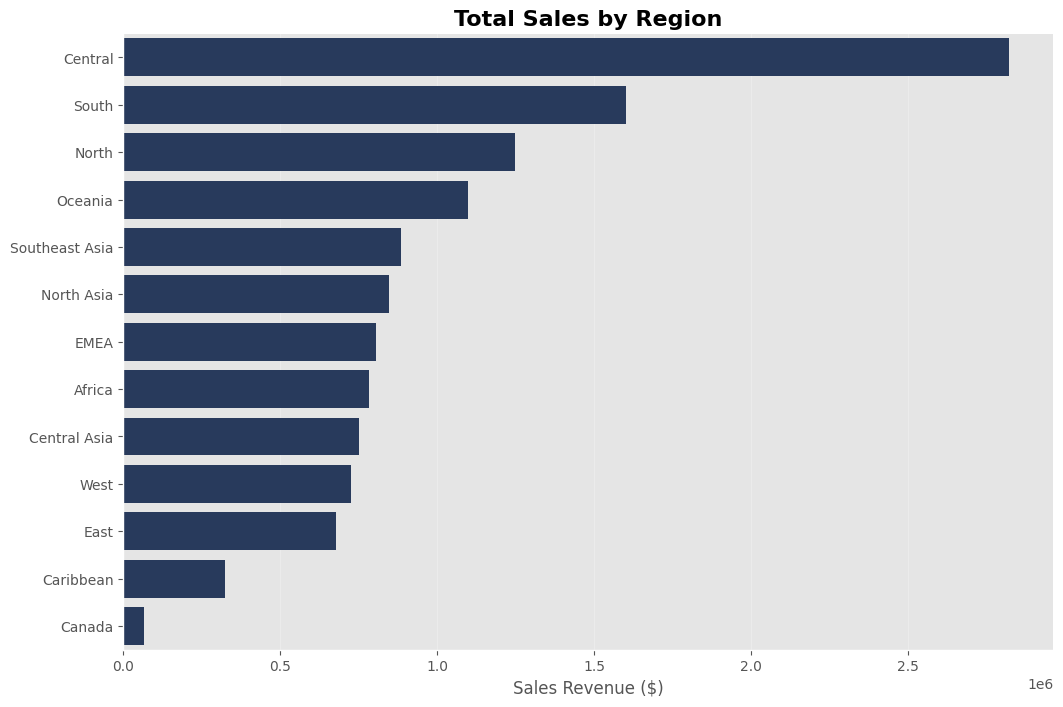

In [44]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=region,
    x="Total_Sales",
    y="Region",
    color="#203864"
)

plt.title(
    "Total Sales by Region",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sales Revenue ($)")
plt.ylabel("")

plt.grid(axis="x", alpha=0.25)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

## Profit by Region

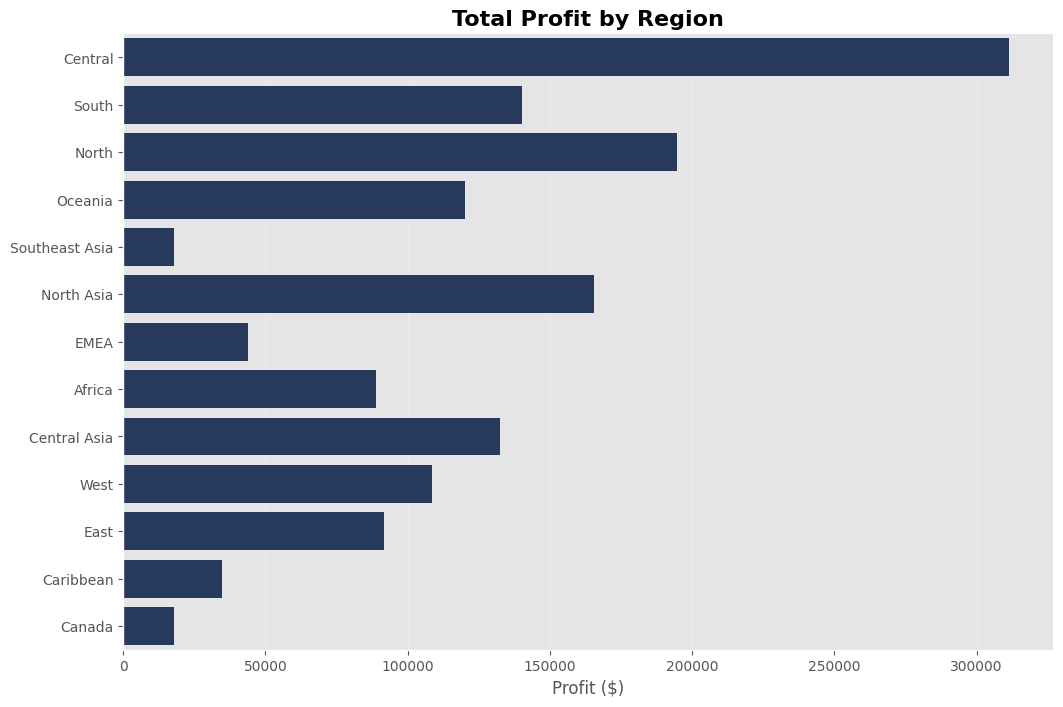

In [46]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=region,
    x="Total_Profit",
    y="Region",
    color="#203864"
)

plt.title(
    "Total Profit by Region",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Profit ($)")
plt.ylabel("")

plt.grid(axis="x", alpha=0.25)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

### Key Findings
* APAC generated the highest sales and profit.
* Europe ranked second in both sales and profitability.
* Southeast Asia generated relatively high sales but comparatively lower profit.

### Business Insight
Business performance varies across regions. While APAC and the Central region are the primary growth drivers, Southeast Asia presents opportunities to improve profitability despite strong sales performance.

## Business Recommendation
* Continue investing in high-performing markets such as APAC and Europe.
* Investigate profitability challenges in Southeast Asia.
* Apply successful operational practices from high-performing regions to lower-performing markets where appropriate.

# Customer Performance Analysis
Which customer segments and individual customers contribute the most to business performance?

## sales by Segment

In [47]:
segment = (
    orders
    .groupby("Segment")
    .agg(
        Total_Sales=("Sales","sum"),
        Total_Profit=("Profit","sum"),
        Total_Orders=("Order ID","count"),
        Total_Customers=("Customer ID","nunique")
    )
    .reset_index()
)

segment

,Segment,Total_Sales,Total_Profit,Total_Orders,Total_Customers
0,Consumer,6.507949e+06,749239.78206,26518,818
1,Corporate,3.824698e+06,441208.32866,15429,476
2,Home Office,2.309855e+06,277009.18056,9343,296


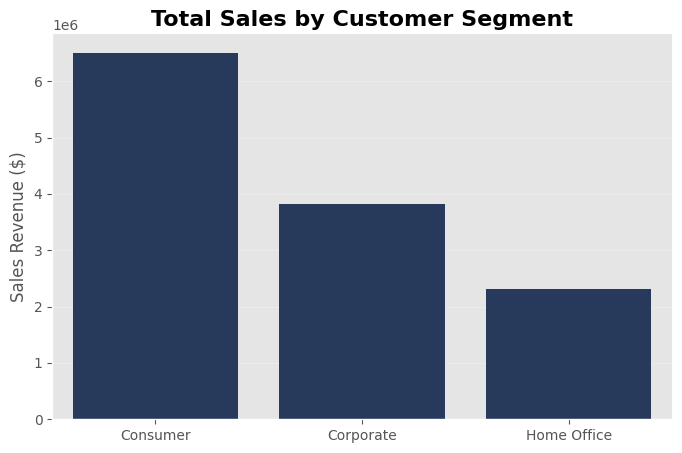

In [48]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=segment,
    x="Segment",
    y="Total_Sales",
    color="#203864"
)

plt.title(
    "Total Sales by Customer Segment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Sales Revenue ($)")

plt.grid(axis="y", alpha=0.25)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

## Profit by Segment

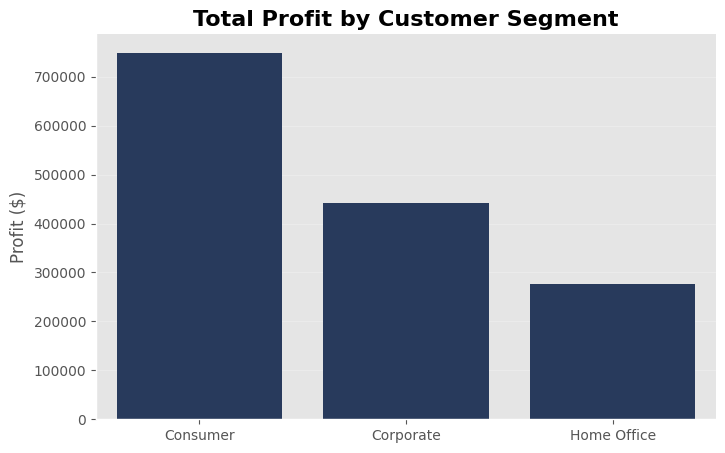

In [49]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=segment,
    x="Segment",
    y="Total_Profit",
    color="#203864"
)

plt.title(
    "Total Profit by Customer Segment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Profit ($)")

plt.grid(axis="y", alpha=0.25)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

# Top 10 Customer by Sales
Who are the highest value customers contributing to total revenue?

In [53]:
top_customer = (
    orders
    .groupby(["Customer ID","Customer Name"])
    .agg(
        Total_Sales=("Sales","sum"),
        Total_Profit=("Profit","sum"),
        Total_Orders=("Order ID","count")
    )
    .reset_index()
    .sort_values("Total_Sales", ascending=False)
    .head(10)
)

top_customer

,Customer ID,Customer Name,Total_Sales,Total_Profit,Total_Orders
1463,TA-21385,Tom Ashbrook,35668.12080,6274.98910,65
623,GT-14710,Greg Tran,34471.89028,5164.84718,74
1489,TC-20980,Tamara Chand,34218.26900,8787.47490,59
1405,SM-20320,Sean Miller,31125.29496,-1083.67434,39
237,BW-11110,Bart Watters,30613.61650,3337.46590,81
656,HL-15040,Hunter Lopez,29664.23058,7657.50178,47
1369,SE-20110,Sanjit Engle,29532.62502,5863.62392,75
1220,PS-19045,Penelope Sewall,29252.31940,4426.19510,72
1243,RB-19360,Raymond Buch,29197.63460,8523.95150,65
1587,ZC-21910,Zuschuss Carroll,28472.81926,452.50326,84


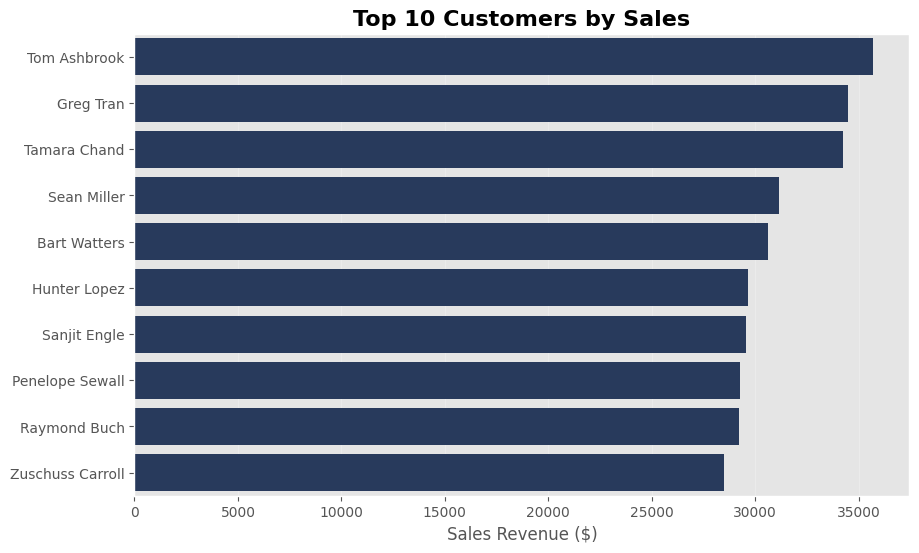

In [54]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_customer,
    x="Total_Sales",
    y="Customer Name",
    color="#203864"
)

plt.title(
    "Top 10 Customers by Sales",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sales Revenue ($)")
plt.ylabel("")

plt.grid(axis="x", alpha=0.25)

plt.show()

### Key Findings
* Consumer generated the highest total sales and profit among all customer segments.
* Corporate ranked second in both sales and profitability, followed by Home Office.
* Tom Ashbrook was the highest-revenue customer, followed by Greg Tran and Tamara Chand, indicating that a small group of customers contributed substantially to total sales.

### Business Insight
While the Consumer segment remains the company's primary revenue driver, identifying top-performing individual customers enables more targeted retention strategies. Strengthening relationships with these high-value customers can help sustain long-term revenue growth and customer loyalty.

### Business Recommendation
* Prioritize retention strategies for high-value customers through personalized engagement and loyalty programs.
* Continue expanding the Consumer customer base while maintaining relationships with top-performing customers.
* Regularly monitor customer contribution to identify opportunities for upselling and cross-selling.

# Executive Summary

## Business Performance
**Summary**

Sales and profit showed an overall upward trend from 2011 to 2014. However, profit exhibited greater fluctuations than sales, indicating that revenue growth alone did not always translate into stable profitability.

## Product Performance

**Sumarry**

Technology was the strongest-performing category, generating both the highest sales and profit. In contrast, Furniture produced relatively high sales but lower profitability. At the sub-category level, Tables emerged as the weakest-performing product, recording negative total profit despite strong sales.

## Root Cause Analysis
**Sumarry**

The analysis identified excessive discounting as the primary factor associated with lower profitability. Average profit declined noticeably when discounts exceeded approximately 20%. While Tables also incurred high shipping costs, shipping cost was not identified as the primary driver of weak financial performance. Furthermore, loss rate analysis revealed hidden transaction-level risks that were not visible through aggregated profit alone.

## Market & Customer Performace
**Summary**

APAC and the Central region were the strongest-performing markets in terms of both sales and profit. The Consumer segment generated the highest overall revenue and profit, while the company's sales performance remained broadly distributed across its customer base. Tom Ashbrook was identified as the highest-value customer by total sales.

# Strategic Recommendations
* Review and optimize discount strategies, particularly for products receiving discounts above 20%.
* Reassess pricing and profitability strategies for the Tables sub-category.
* Continue investing in high-performing categories and markets, particularly Technology and APAC.
* Strengthen retention programs for high-value customers through personalized engagement.
* Incorporate transaction-level metrics, such as loss rate, alongside sales and profit to support more comprehensive business decision-making.

Overall, this analysis demonstrates that business performance should be evaluated using multiple dimensions rather than sales alone. By combining profitability, discount effectiveness, transaction-level risk, market performance, and customer contribution, the company can make more informed and sustainable business decisions.